<a href="https://www.kaggle.com/code/nowrinbegumr/walmart-sales-forecasting?scriptVersionId=327322134" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nowrinbegumr/walmart-store-sales-csv/Walmart_Store_sales.csv


In [2]:
import glob
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.arima.model import ARIMA  # type: ignore
from statsmodels.tsa.holtwinters import ExponentialSmoothing  # type: ignore
from statsmodels.tsa.seasonal import seasonal_decompose  # type: ignore
from statsmodels.tsa.statespace.sarimax import SARIMAX  # type: ignore
from statsmodels.tsa.stattools import adfuller  # type: ignore
from tensorflow import keras  # type: ignore
from tensorflow.keras import callbacks, layers  # type: ignore

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style='whitegrid')
np.random.seed(42)

def safe_mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.where(np.abs(y_true) < 1e-8, np.nan, y_true)
    return np.nanmean(np.abs((y_true - y_pred) / denom)) * 100

def evaluate_forecast(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return pd.DataFrame([
        {
            'Model': model_name,
            'MAE': mean_absolute_error(y_true, y_pred),
            'RMSE': rmse,
            'MAPE (%)': safe_mape(y_true, y_pred)
        }
    ])

def plot_forecast(train_series, test_series, forecast_series, title):
    plt.figure(figsize=(14, 5))
    plt.plot(train_series.index, train_series, label='Train')
    plt.plot(test_series.index, test_series, label='Test')
    plt.plot(forecast_series.index, forecast_series, label='Forecast')
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Weekly Sales')
    plt.legend()
    plt.tight_layout()
    plt.show()

def create_sequences(values, lookback):
    X, y = [], []
    for i in range(lookback, len(values)):
        X.append(values[i - lookback:i, 0])
        y.append(values[i, 0])
    return np.array(X), np.array(y)

2026-06-15 08:24:51.108323: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781511891.435211      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781511891.515411      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781511892.229350      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781511892.229411      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781511892.229416      16 computation_placer.cc:177] computation placer alr

In [3]:
def find_dataset_path():
    preferred_name = 'Walmart_Store_sales.csv'
    candidates = glob.glob('/kaggle/input/**/*.csv', recursive=True) + glob.glob('*.csv')
    if not candidates:
        raise FileNotFoundError('No CSV file found in the notebook environment.')
    preferred = [path for path in candidates if path.endswith(preferred_name)]
    return preferred[0] if preferred else candidates[0]

dataset_path = find_dataset_path()
dataset = pd.read_csv(dataset_path)

dataset['Date'] = pd.to_datetime(dataset['Date'], format='%d-%m-%Y')
dataset = dataset.sort_values(['Store', 'Date']).reset_index(drop=True)

print('Dataset path:', dataset_path)
print('Shape:', dataset.shape)
dataset.info()
display(dataset.head())

weekly_sales = (
    dataset.groupby('Date', as_index=True)['Weekly_Sales']
    .sum()
    .sort_index()
    .to_frame()
)

weekly_sales = weekly_sales.asfreq('W-FRI')
weekly_sales['Weekly_Sales'] = weekly_sales['Weekly_Sales'].interpolate(method='time')
series = weekly_sales['Weekly_Sales']

split_index = int(len(series) * 0.8)
train = series.iloc[:split_index]
test = series.iloc[split_index:]

print('Train size:', len(train))
print('Test size:', len(test))
display(weekly_sales.head())

Dataset path: /kaggle/input/datasets/nowrinbegumr/walmart-store-sales-csv/Walmart_Store_sales.csv
Shape: (6435, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 402.3 KB


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106


Train size: 114
Test size: 29


,Weekly_Sales
Date,
2010-02-05,49750740.50
2010-02-12,48336677.63
2010-02-19,48276993.78
2010-02-26,43968571.13
2010-03-05,46871470.30


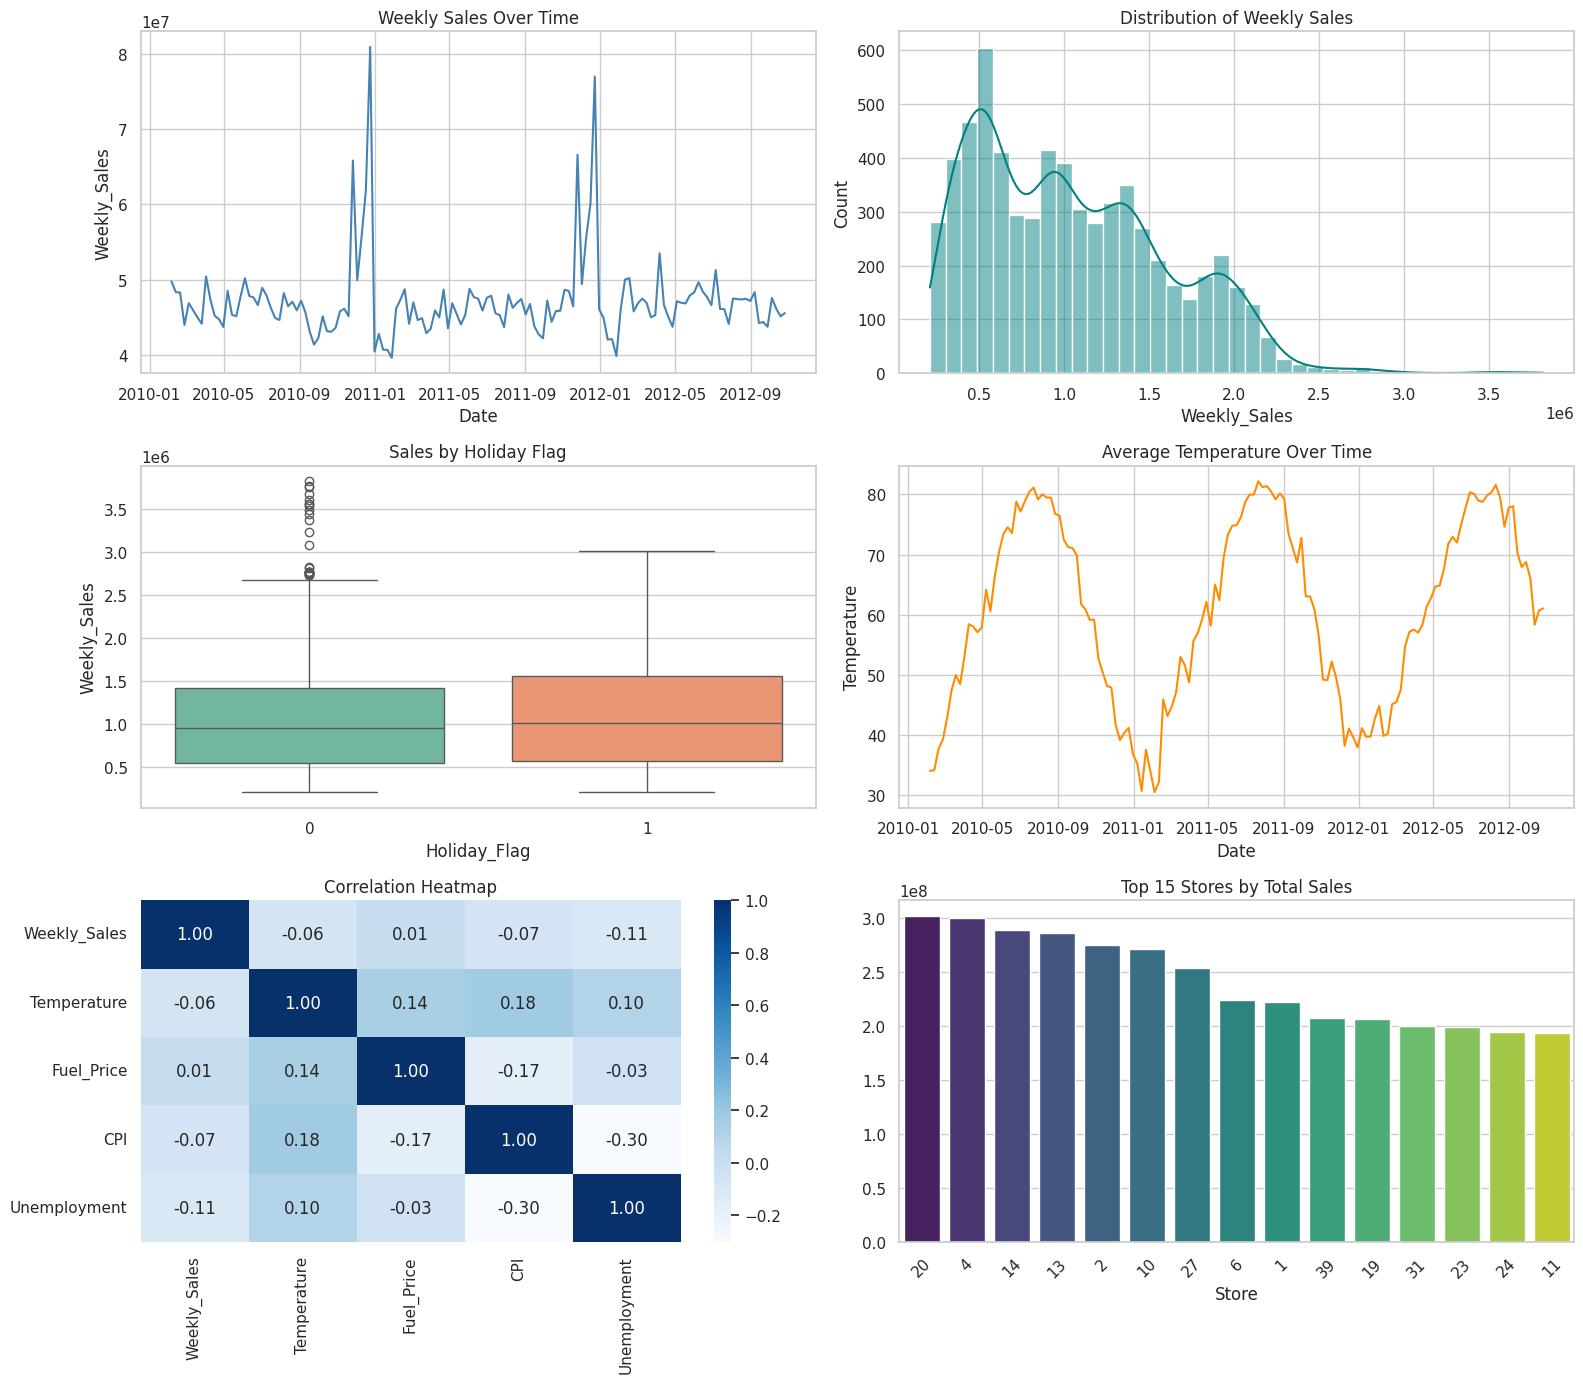

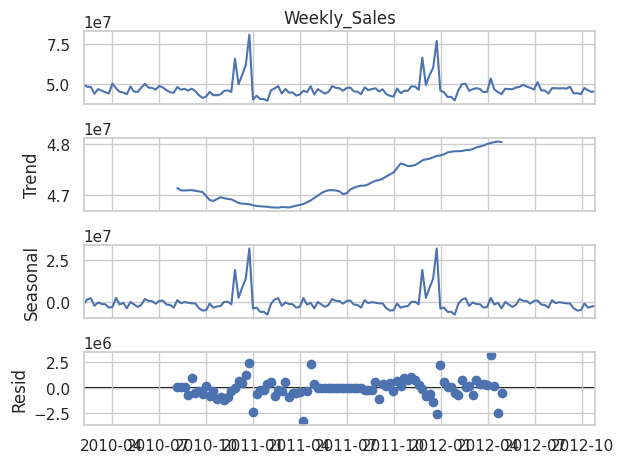

               count          mean            std         min         25%  \
Weekly_Sales  6435.0  1.046965e+06  564366.622054  209986.250  553350.105   
Temperature   6435.0  6.066378e+01      18.444933      -2.060      47.460   
Fuel_Price    6435.0  3.358607e+00       0.459020       2.472       2.933   
CPI           6435.0  1.715784e+02      39.356712     126.064     131.735   
Unemployment  6435.0  7.999151e+00       1.875885       3.879       6.891   

                        50%           75%           max  
Weekly_Sales  960746.040000  1.420159e+06  3.818686e+06  
Temperature       62.670000  7.494000e+01  1.001400e+02  
Fuel_Price         3.445000  3.735000e+00  4.468000e+00  
CPI              182.616521  2.127433e+02  2.272328e+02  
Unemployment       7.874000  8.622000e+00  1.431300e+01  


In [4]:
numeric_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
sales_time = weekly_sales.reset_index()
temp_time = dataset.groupby('Date', as_index=False)['Temperature'].mean()

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

sns.lineplot(data=sales_time, x='Date', y='Weekly_Sales', ax=axes[0], color='steelblue')
axes[0].set_title('Weekly Sales Over Time')
axes[0].set_xlabel('Date')

sns.histplot(dataset['Weekly_Sales'], kde=True, ax=axes[1], color='teal')
axes[1].set_title('Distribution of Weekly Sales')

sns.boxplot(x=dataset['Holiday_Flag'], y=dataset['Weekly_Sales'], ax=axes[2], palette='Set2')
axes[2].set_title('Sales by Holiday Flag')

sns.lineplot(data=temp_time, x='Date', y='Temperature', ax=axes[3], color='darkorange')
axes[3].set_title('Average Temperature Over Time')

corr = dataset[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='Blues', ax=axes[4], fmt='.2f')
axes[4].set_title('Correlation Heatmap')

sales_by_store = dataset.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False).head(15)
sns.barplot(x=sales_by_store.index.astype(str), y=sales_by_store.values, ax=axes[5], palette='viridis')
axes[5].set_title('Top 15 Stores by Total Sales')
axes[5].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

decomp_period = 52 if len(series) >= 104 else max(2, min(12, len(series) // 2))
decomposition = seasonal_decompose(series, model='additive', period=decomp_period)
decomposition.plot()
plt.tight_layout()
plt.show()

print(dataset[numeric_cols].describe().T)

,Model,MAE,RMSE,MAPE (%)
0,ETS,1.823327e+06,2.192052e+06,3.941249


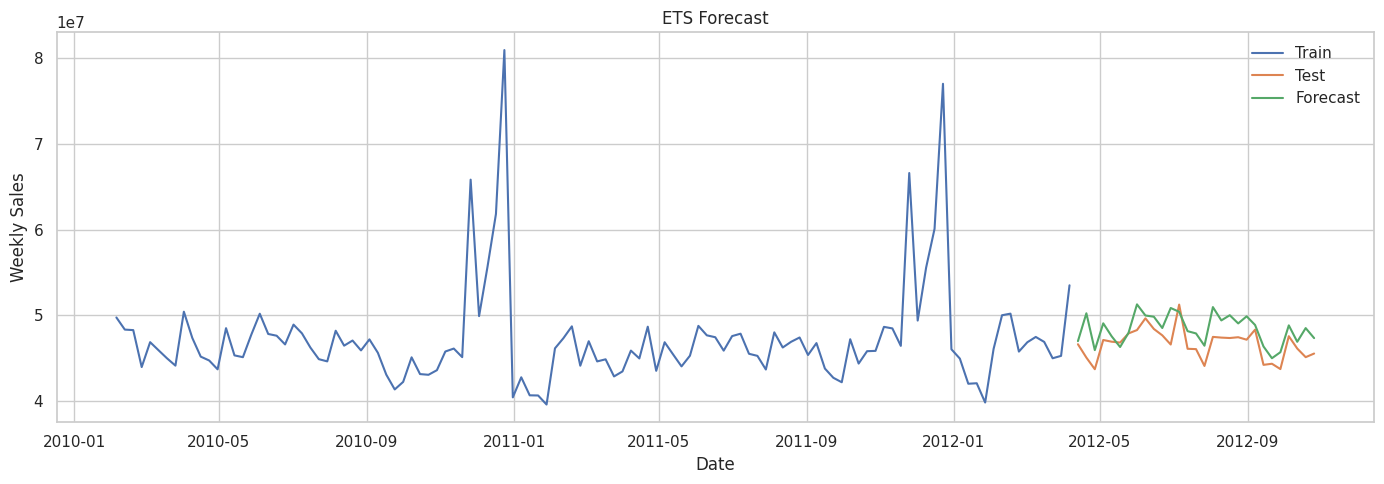

In [5]:
ets_seasonal_period = 52 if len(train) >= 104 else 12

ets_model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='add',
    seasonal_periods=ets_seasonal_period,
    initialization_method='estimated'
)
ets_fit = ets_model.fit(optimized=True)
ets_forecast = ets_fit.forecast(len(test))
ets_forecast = pd.Series(ets_forecast.values, index=test.index)

ets_metrics = evaluate_forecast(test, ets_forecast, 'ETS')
display(ets_metrics)
plot_forecast(train, test, ets_forecast, 'ETS Forecast')

ADF statistic: -5.273240474947425
ADF p-value: 6.219568401203383e-06
Best ARIMA order: (1, 1, 3)


,Model,MAE,RMSE,MAPE (%)
0,ARIMA,2.079464e+06,2.562539e+06,4.544052


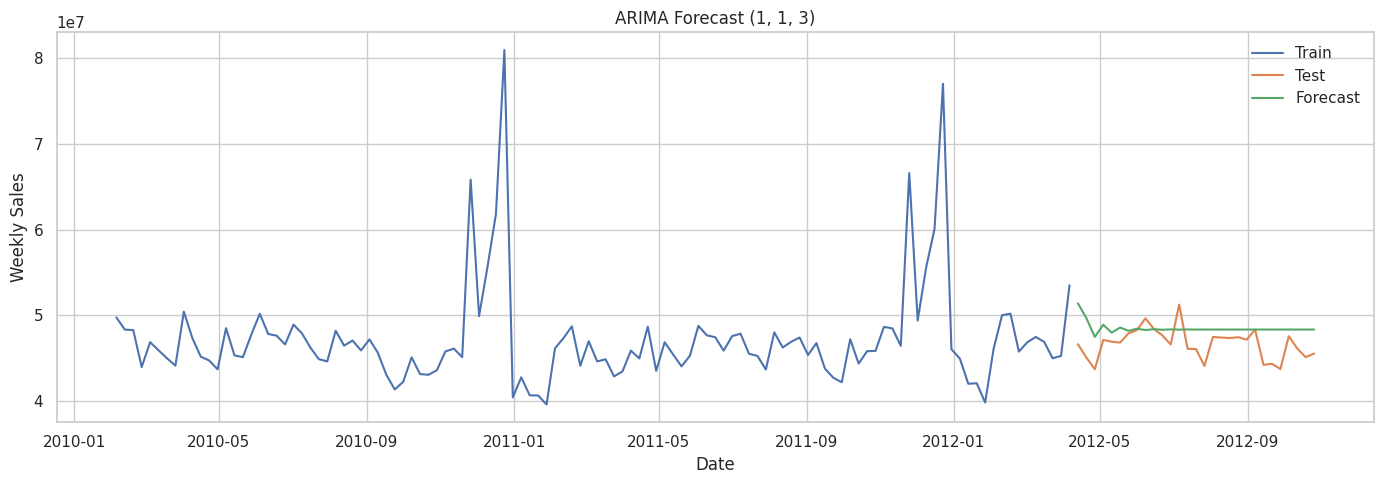

In [6]:
adf_stat, adf_pvalue, *_ = adfuller(train)
print('ADF statistic:', adf_stat)
print('ADF p-value:', adf_pvalue)

best_arima = {'aic': np.inf, 'order': None, 'fit': None}
for p in range(0, 4):
    for d in range(0, 2):
        for q in range(0, 4):
            try:
                fit = ARIMA(train, order=(p, d, q)).fit()
                if fit.aic < best_arima['aic']:
                    best_arima = {'aic': fit.aic, 'order': (p, d, q), 'fit': fit}
            except Exception:
                continue

if best_arima['fit'] is None:
    raise RuntimeError('ARIMA grid search did not return a valid model.')

arima_order = best_arima['order']
print('Best ARIMA order:', arima_order)
arima_forecast = best_arima['fit'].forecast(steps=len(test))
arima_forecast = pd.Series(arima_forecast.values, index=test.index)

arima_metrics = evaluate_forecast(test, arima_forecast, 'ARIMA')
display(arima_metrics)
plot_forecast(train, test, arima_forecast, f'ARIMA Forecast {arima_order}')

Best SARIMA order: (0, 1, 1)
Best SARIMA seasonal order: (0, 1, 1, 52)


,Model,MAE,RMSE,MAPE (%)
0,SARIMA,7.644146e+06,7.832613e+06,16.459421


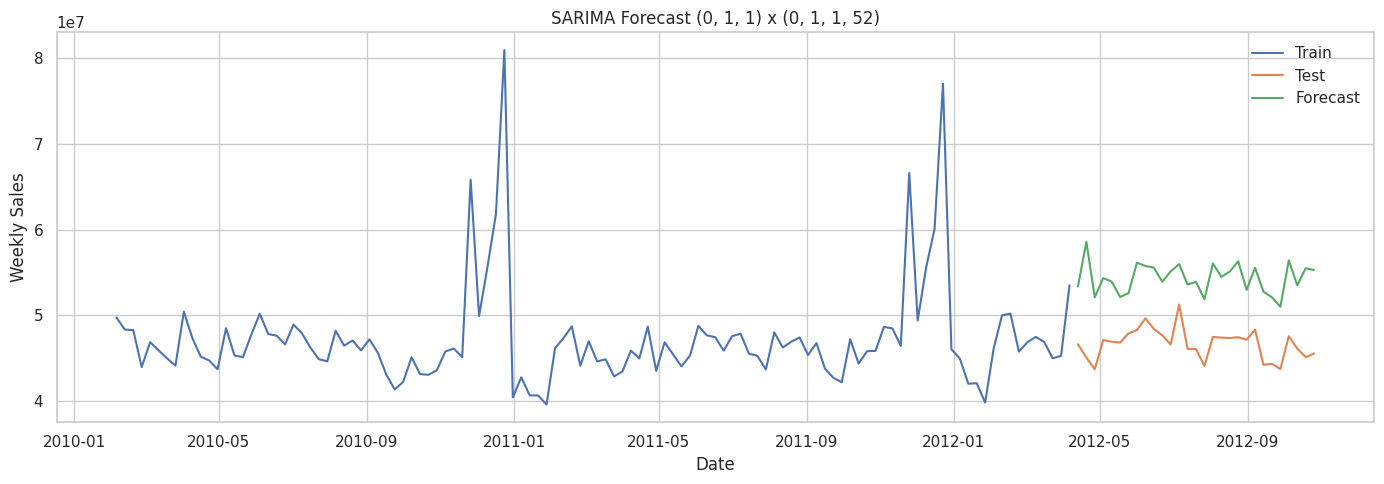

In [7]:
seasonal_period = 52 if len(train) >= 104 else 12
candidate_orders = [(0, 1, 1), (1, 1, 0), (1, 1, 1), (2, 1, 1)]
candidate_seasonal_orders = [
    (0, 1, 1, seasonal_period),
    (1, 1, 0, seasonal_period),
    (1, 1, 1, seasonal_period)
]

best_sarima = {'aic': np.inf, 'order': None, 'seasonal_order': None, 'fit': None}
for order in candidate_orders:
    for seasonal_order in candidate_seasonal_orders:
        try:
            fit = SARIMAX(
                train,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            ).fit(disp=False)
            if fit.aic < best_sarima['aic']:
                best_sarima = {
                    'aic': fit.aic,
                    'order': order,
                    'seasonal_order': seasonal_order,
                    'fit': fit
                }
        except Exception:
            continue

if best_sarima['fit'] is None:
    raise RuntimeError('SARIMA grid search did not return a valid model.')

sarima_order = best_sarima['order']
sarima_seasonal_order = best_sarima['seasonal_order']
print('Best SARIMA order:', sarima_order)
print('Best SARIMA seasonal order:', sarima_seasonal_order)

sarima_forecast = best_sarima['fit'].forecast(steps=len(test))
sarima_forecast = pd.Series(sarima_forecast.values, index=test.index)

sarima_metrics = evaluate_forecast(test, sarima_forecast, 'SARIMA')
display(sarima_metrics)
plot_forecast(train, test, sarima_forecast, f'SARIMA Forecast {sarima_order} x {sarima_seasonal_order}')

2026-06-15 08:26:15.526675: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


,Model,MAE,RMSE,MAPE (%)
0,LSTM,1.406129e+06,1.736291e+06,3.036215


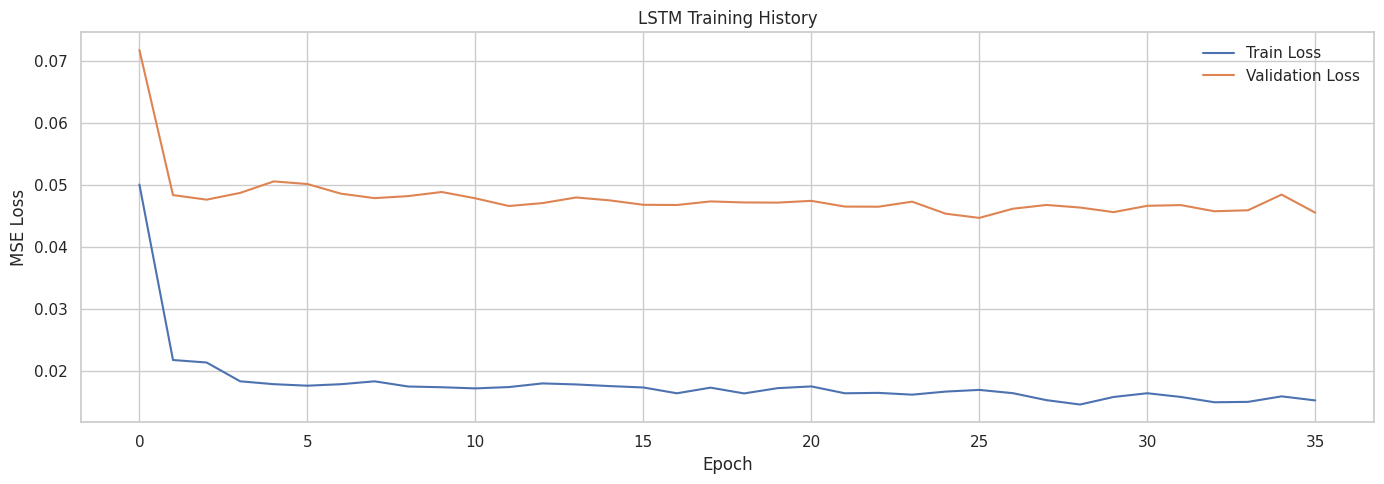

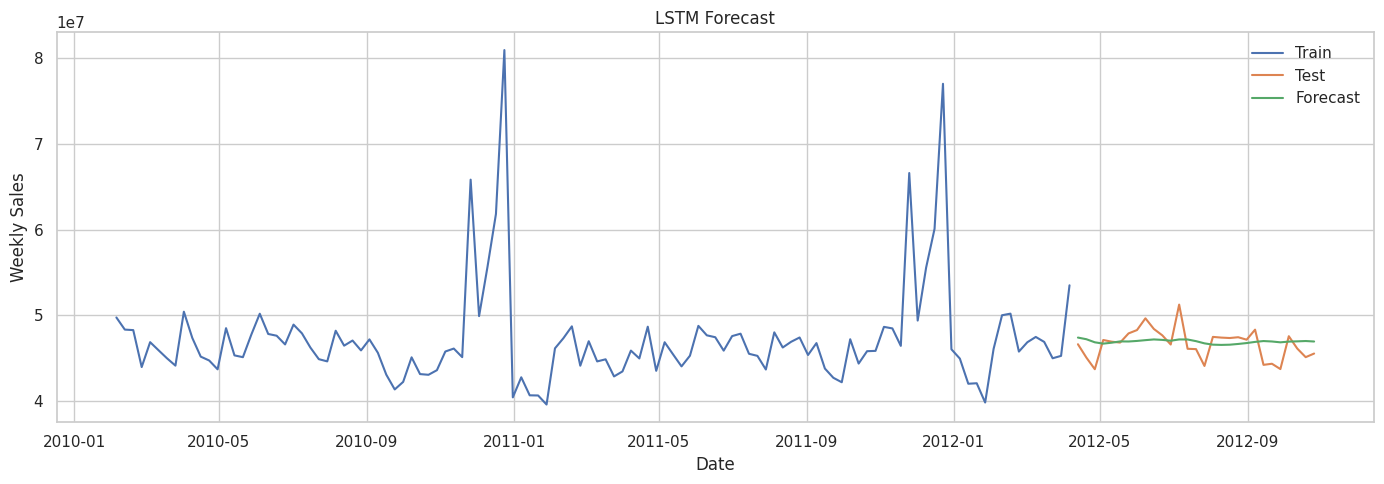

In [8]:
lookback = 12

import importlib

tf = importlib.import_module('tensorflow')
keras = tf.keras
callbacks = keras.callbacks
layers = keras.layers
try:
    tf.config.set_visible_devices([], 'GPU')
except Exception:
    pass

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train.values.reshape(-1, 1))
test_scaled = scaler.transform(test.values.reshape(-1, 1))

X_train, y_train = create_sequences(train_scaled, lookback)
X_test_input = np.concatenate([train_scaled[-lookback:], test_scaled], axis=0)
X_test, y_test = create_sequences(X_test_input, lookback)

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

lstm_model = keras.Sequential([
    layers.Input(shape=(lookback, 1)),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(32),
    layers.Dropout(0.2),
    layers.Dense(1)
])

lstm_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mse')
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = lstm_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    callbacks=[early_stop],
    verbose=0,
    shuffle=False
)

lstm_pred_scaled = lstm_model.predict(X_test, verbose=0)
lstm_forecast = pd.Series(
    scaler.inverse_transform(lstm_pred_scaled).ravel(),
    index=test.index
)

lstm_metrics = evaluate_forecast(test, lstm_forecast, 'LSTM')
display(lstm_metrics)

plt.figure(figsize=(14, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Training History')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

plot_forecast(train, test, lstm_forecast, 'LSTM Forecast')

In [9]:
model_results = pd.concat([ets_metrics, arima_metrics, sarima_metrics, lstm_metrics], ignore_index=True)
model_results = model_results.sort_values('RMSE').reset_index(drop=True)
display(model_results)

best_model_name = model_results.loc[0, 'Model']
print('Best model based on RMSE:', best_model_name)

,Model,MAE,RMSE,MAPE (%)
0,LSTM,1.406129e+06,1.736291e+06,3.036215
1,ETS,1.823327e+06,2.192052e+06,3.941249
2,ARIMA,2.079464e+06,2.562539e+06,4.544052
3,SARIMA,7.644146e+06,7.832613e+06,16.459421


Best model based on RMSE: LSTM


,Forecasted Weekly Sales
2012-11-02,47047736.0
2012-11-09,47329936.0
2012-11-16,47625304.0
2012-11-23,47869604.0
2012-11-30,48019440.0
2012-12-07,48086400.0
2012-12-14,47974288.0
2012-12-21,47810880.0
2012-12-28,47602340.0
2013-01-04,47437704.0


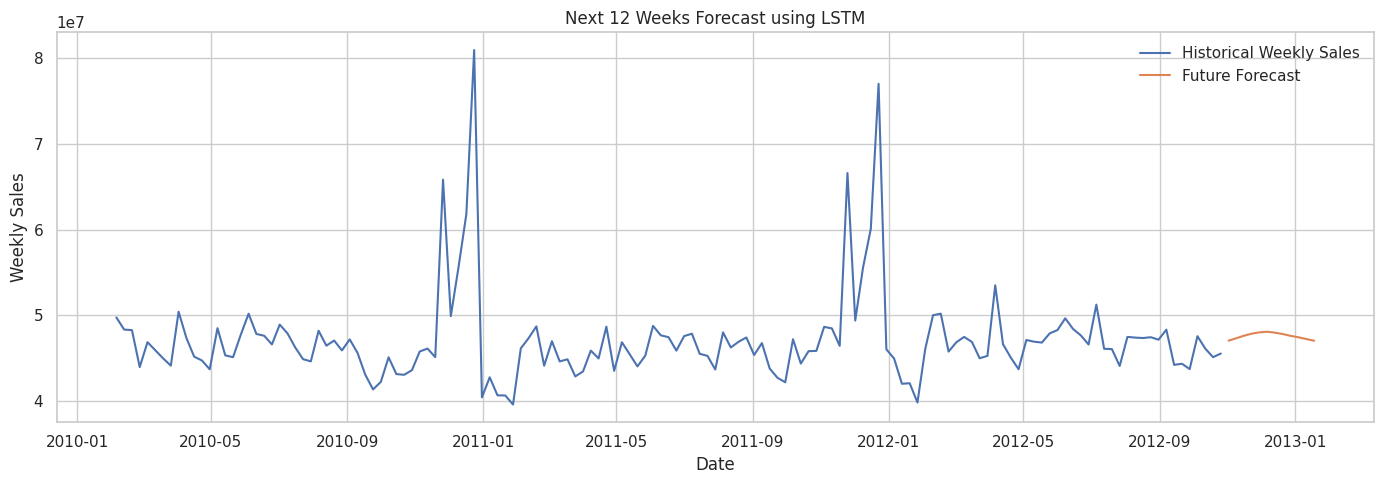

In [10]:
future_steps = 12
future_index = pd.date_range(series.index[-1] + pd.Timedelta(weeks=1), periods=future_steps, freq='W-FRI')

if best_model_name == 'ETS':
    final_fit = ExponentialSmoothing(
        series,
        trend='add',
        seasonal='add',
        seasonal_periods=ets_seasonal_period,
        initialization_method='estimated'
    ).fit(optimized=True)
    future_forecast = pd.Series(final_fit.forecast(future_steps).values, index=future_index)
elif best_model_name == 'ARIMA':
    final_fit = ARIMA(series, order=arima_order).fit()
    future_forecast = pd.Series(final_fit.forecast(future_steps).values, index=future_index)
elif best_model_name == 'SARIMA':
    final_fit = SARIMAX(
        series,
        order=sarima_order,
        seasonal_order=sarima_seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)
    future_forecast = pd.Series(final_fit.forecast(future_steps).values, index=future_index)
else:
    import importlib

    tf = importlib.import_module('tensorflow')
    keras = tf.keras
    callbacks = keras.callbacks
    layers = keras.layers
    try:
        tf.config.set_visible_devices([], 'GPU')
    except Exception:
        pass

    final_scaler = MinMaxScaler()
    full_scaled = final_scaler.fit_transform(series.values.reshape(-1, 1))
    X_full, y_full = create_sequences(full_scaled, lookback)
    X_full = X_full.reshape((X_full.shape[0], X_full.shape[1], 1))

    final_lstm = keras.Sequential([
        layers.Input(shape=(lookback, 1)),
        layers.LSTM(64, return_sequences=True),
        layers.Dropout(0.2),
        layers.LSTM(32),
        layers.Dropout(0.2),
        layers.Dense(1)
    ])
    final_lstm.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mse')
    final_lstm.fit(X_full, y_full, epochs=50, batch_size=16, verbose=0, shuffle=False)

    history_window = full_scaled[-lookback:].copy()
    future_scaled_predictions = []

    for _ in range(future_steps):
        next_scaled = final_lstm.predict(history_window.reshape(1, lookback, 1), verbose=0)[0, 0]
        future_scaled_predictions.append(next_scaled)
        history_window = np.vstack([history_window[1:], [[next_scaled]]])

    future_forecast = pd.Series(
        final_scaler.inverse_transform(np.array(future_scaled_predictions).reshape(-1, 1)).ravel(),
        index=future_index
    )

display(future_forecast.to_frame(name='Forecasted Weekly Sales'))

plt.figure(figsize=(14, 5))
plt.plot(series.index, series, label='Historical Weekly Sales')
plt.plot(future_forecast.index, future_forecast, label='Future Forecast')
plt.title(f'Next {future_steps} Weeks Forecast using {best_model_name}')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.tight_layout()
plt.show()

## 9. Conclusion

This notebook builds a complete forecasting workflow for retail weekly sales. It starts with business framing and EDA, then trains ETS, ARIMA, SARIMA, and LSTM models on the same train/test split.

The comparison table identifies the strongest model on the holdout period, and the final section uses that model to produce a forward forecast for the next 12 weeks.
